# Part 2: Support Vector Machine Regression

## 2.1 Overview 

In Part 2 we investigate how different kernels affect the performance of Support Vector Machine (SVM) regression.  
We generate synthetic toy datasets using random polynomial functions of varying degrees and add Gaussian noise.  
These datasets will later be used to train and evaluate `sklearn.svm.SVR` models with linear, polynomial, and RBF kernels.

**Methodology**  
- We implement a reusable function to generate polynomial data as specified in the assignment.  
- We demonstrate the function by visualising example datasets (Task 1).  
- We then create three larger datasets (linear, quadratic, cubic) with 1000 samples each and split them into training/test sets (Task 2).  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# For reproducibility across all random operations
np.random.seed(42)

## 2.2 Task 1 – Polynomial Dataset Generation Function

We implement a function `generate_polynomial_dataset(degree, n_samples)` that creates data of the form  

$$ y = \sum_{k=0}^{n} a_k x^k + \epsilon $$  

where  
- $x \in [-3, 3]$,  
- $a_k \sim \mathcal{U}(0, 1)$,  
- $\epsilon \sim \mathcal{N}(0, 1)$.  

The function returns the feature matrix `X` (shape `(n_samples, 1)`) and target vector `y` (shape `(n_samples,)`).  
For visualisation we also return the true polynomial coefficients.

In [2]:
def generate_polynomial_dataset(degree, n_samples):
    # Generate x values
    X = np.random.uniform(-3, 3, n_samples).reshape(-1, 1)
    
    # Random coefficients a_k ~ Uniform(0, 1)
    coefficients = np.random.uniform(0, 1, degree + 1)
    
    # Compute true polynomial values (vectorised)
    y_true = np.zeros(n_samples)
    for k in range(degree + 1):
        y_true += coefficients[k] * (X[:, 0] ** k)
    
    # Add Gaussian noise ε ~ N(0, 1)
    epsilon = np.random.normal(0, 1, n_samples)
    y = y_true + epsilon
    
    return X, y, coefficients

### Demonstration – Visualising Generated Datasets

To verify the function works correctly we generate and plot datasets for degrees 1, 2 and 3 (100 samples each).  
The red line shows the underlying **ground-truth** polynomial (without noise).

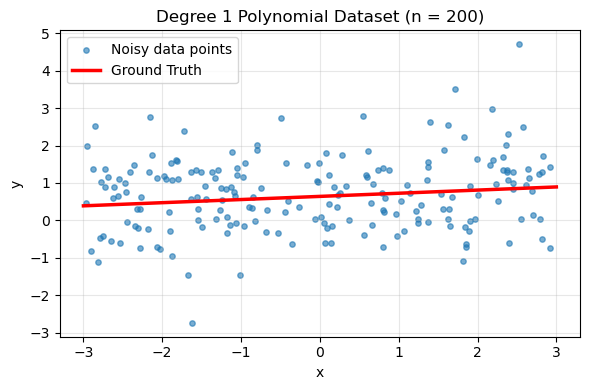

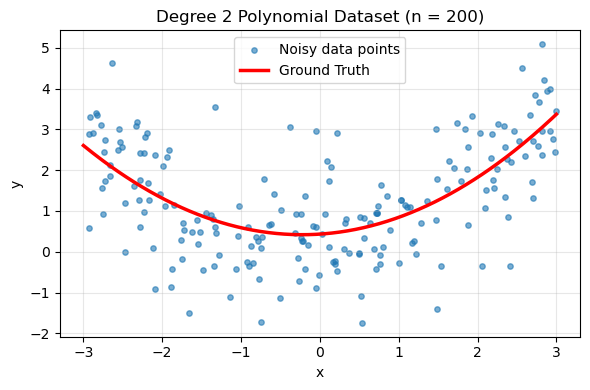

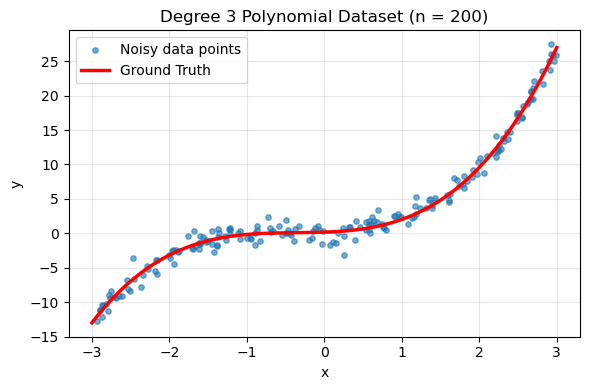

In [3]:
def plot_generated_dataset(degree, n_samples=200, figsize=(6, 4)):
    """Helper to visualise a generated polynomial dataset with ground truth."""
    X, y, coeffs = generate_polynomial_dataset(degree, n_samples)
    
    plt.figure(figsize=figsize)
    # Noisy data points
    plt.scatter(X.flatten(), y, s=15, alpha=0.6, label='Noisy data points')
    
    # Ground-truth polynomial curve
    x_plot = np.linspace(-3, 3, 300)
    # np.polyval expects coefficients from highest to lowest degree
    y_true_plot = np.polyval(coeffs[::-1], x_plot)
    plt.plot(x_plot, y_true_plot, 'r-', linewidth=2.5, label='Ground Truth')
    
    plt.title(f'Degree {degree} Polynomial Dataset (n = {n_samples})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Show example datasets for degrees 1, 2 and 3
plot_generated_dataset(1, n_samples=200)
plot_generated_dataset(2, n_samples=200)
plot_generated_dataset(3, n_samples=200)

**Observation**  
The plots match the expected behaviour shown in Figure 1 of the assignment:  
- Degree 1 produces a straight line with random slope and intercept.  
- Degree 2 produces a parabolic shape.  
- Degree 3 produces a more complex cubic curve.  
The noise level is consistent with $\epsilon \sim \mathcal{N}(0, 1)$.

## 2.3 Task 2 – Generate Linear, Quadratic and Cubic Datasets

We now create three larger datasets (1000 samples each) using the function above:  
- Linear (degree = 1)  
- Quadratic (degree = 2)  
- Cubic (degree = 3)  

Each dataset is split into **80 % training** and **20 % test** sets using `train_test_split` with `random_state=42` for reproducibility.

In [4]:
# Generate the three required datasets (n_samples = 1000)
X_lin, y_lin, _ = generate_polynomial_dataset(degree=1, n_samples=1000)
X_quad, y_quad, _ = generate_polynomial_dataset(degree=2, n_samples=1000)
X_cubic, y_cubic, _ = generate_polynomial_dataset(degree=3, n_samples=1000)

# Split each dataset into train (80%) and test (20%)
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

X_train_quad, X_test_quad, y_train_quad, y_test_quad = train_test_split(
    X_quad, y_quad, test_size=0.2, random_state=42
)

X_train_cubic, X_test_cubic, y_train_cubic, y_test_cubic = train_test_split(
    X_cubic, y_cubic, test_size=0.2, random_state=42
)

# Verify shapes
print("Linear dataset  -> Train:", X_train_lin.shape, "Test:", X_test_lin.shape)
print("Quadratic dataset -> Train:", X_train_quad.shape, "Test:", X_test_quad.shape)
print("Cubic dataset    -> Train:", X_train_cubic.shape, "Test:", X_test_cubic.shape)

Linear dataset  -> Train: (800, 1) Test: (200, 1)
Quadratic dataset -> Train: (800, 1) Test: (200, 1)
Cubic dataset    -> Train: (800, 1) Test: (200, 1)


**Summary of generated datasets**  

| Dataset   | Degree | Total samples | Train samples | Test samples |
|-----------|--------|---------------|---------------|--------------|
| Linear    | 1      | 1000          | 800           | 200          |
| Quadratic | 2      | 1000          | 800           | 200          |
| Cubic     | 3      | 1000          | 800           | 200          |

These training and test sets are now ready for the SVM regression experiments in the subsequent tasks (3–5).  
The same random seed guarantees that every run of the notebook produces identical datasets.

## 2.4 Task 3 – Experiment with Different SVR Kernels

**Methodology**  
We now fit an `sklearn.svm.SVR` model to each of the three datasets (linear, quadratic, cubic) using three different kernels:  
- `kernel='linear'`  
- `kernel='poly'` (default degree = 3)  
- `kernel='rbf'`  

All models use the **default hyperparameters**.  
For each dataset–kernel pair we:  
1. Train the SVR **only on the training set**.  
2. Predict on a fine grid of 300 points $x \in [-3, 3]$.  
3. Visualise:  
   - Training points (blue)  
   - Test points (orange) – to observe generalisation  
   - The fitted regression curve (red)  

We produce **one figure per dataset** (3 subplots each) for easy visual comparison.

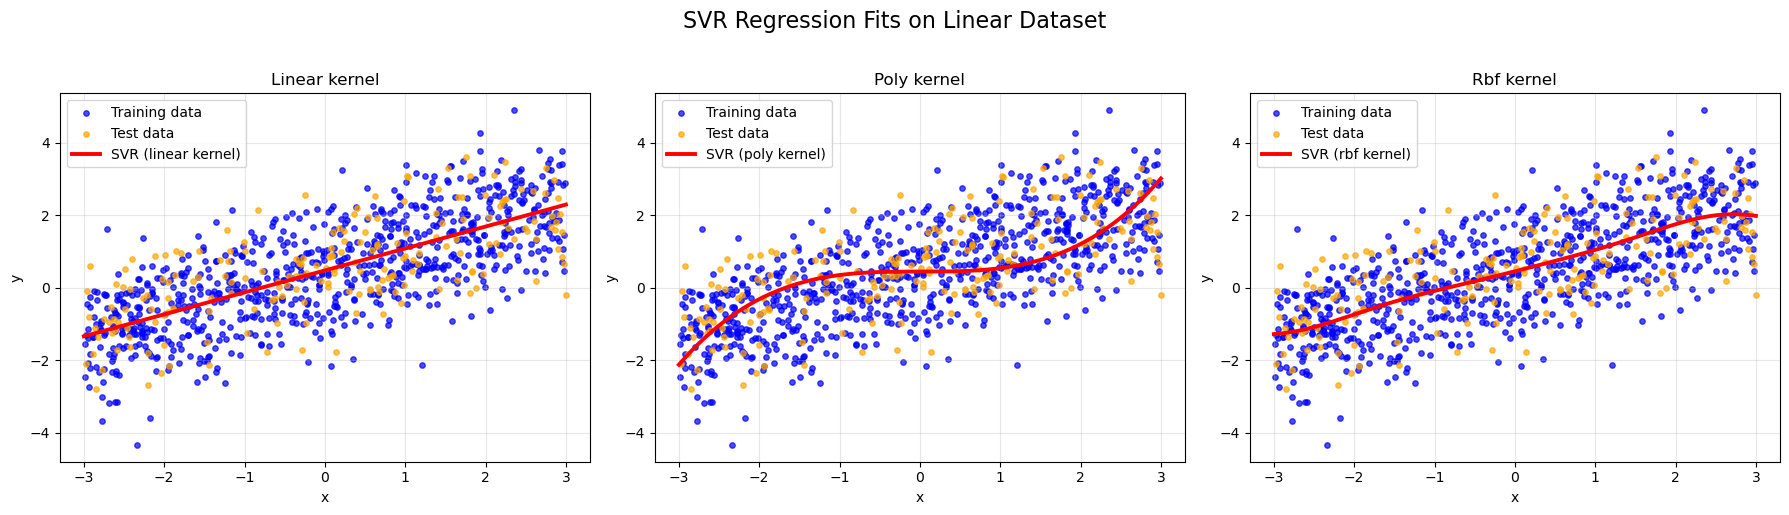

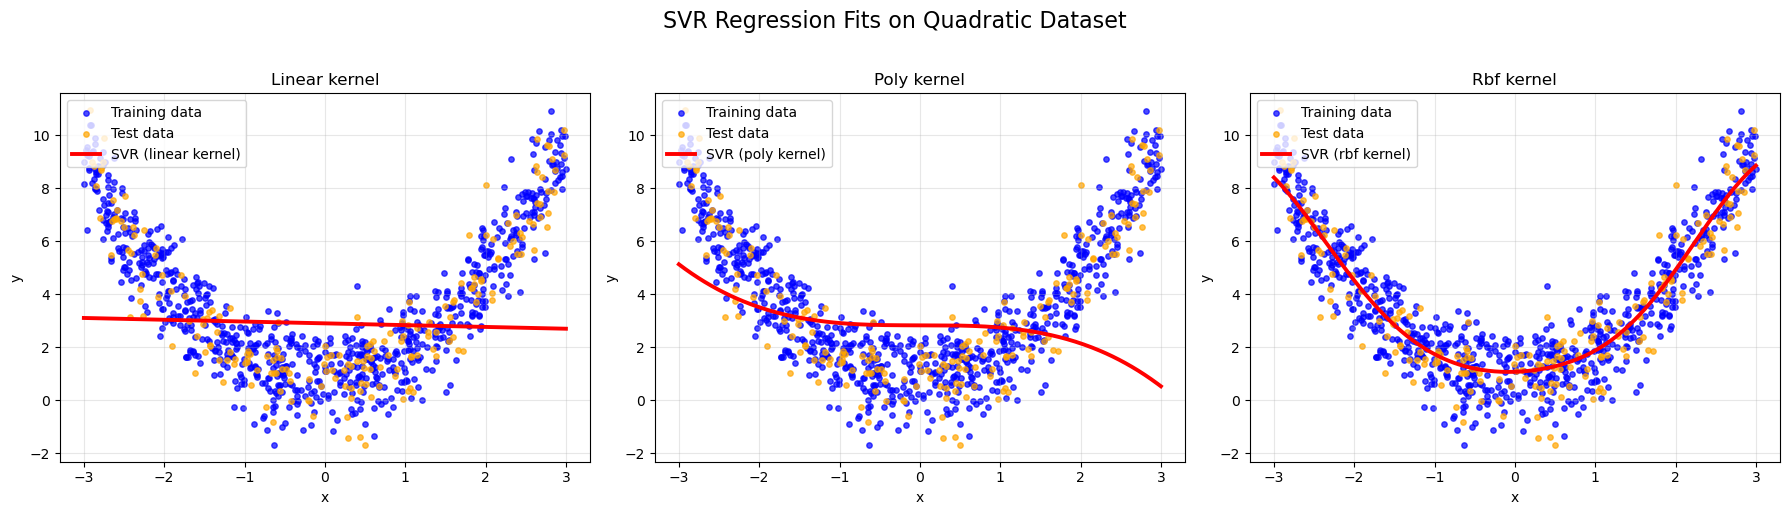

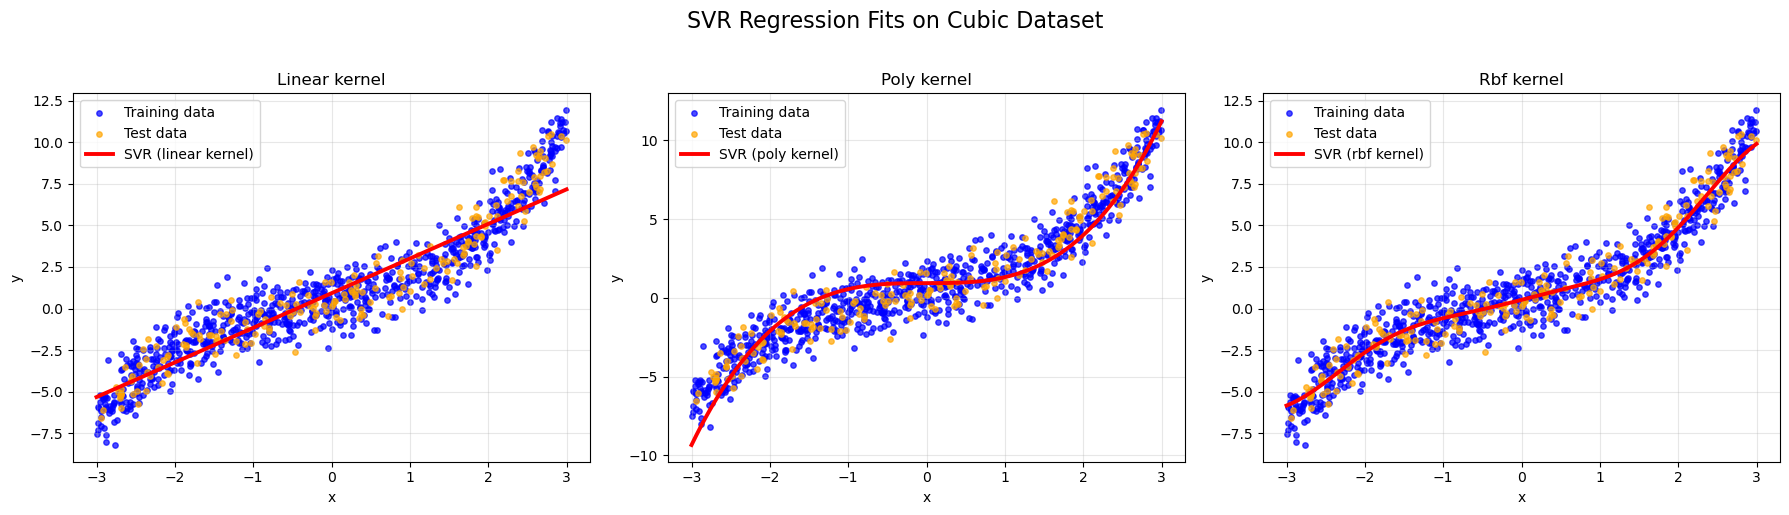

In [5]:
from sklearn.svm import SVR

# Prepare datasets for easy looping (train + test included for visualisation)
datasets = {
    'Linear': (X_train_lin, y_train_lin, X_test_lin, y_test_lin),
    'Quadratic': (X_train_quad, y_train_quad, X_test_quad, y_test_quad),
    'Cubic': (X_train_cubic, y_train_cubic, X_test_cubic, y_test_cubic)
}

kernels = ['linear', 'poly', 'rbf']

for name, (X_train, y_train, X_test, y_test) in datasets.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'SVR Regression Fits on {name} Dataset', fontsize=16, y=1.02)
    
    for j, kernel in enumerate(kernels):
        ax = axes[j]
        
        # Train SVR with the chosen kernel
        svr = SVR(kernel=kernel)
        svr.fit(X_train, y_train)
        
        # Predict on a dense grid for smooth curve
        x_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
        y_pred = svr.predict(x_plot)
        
        # Plot data points
        ax.scatter(X_train.flatten(), y_train, s=15, alpha=0.7, color='blue', label='Training data')
        ax.scatter(X_test.flatten(), y_test, s=15, alpha=0.7, color='orange', label='Test data')
        
        # Plot fitted regression function
        ax.plot(x_plot.flatten(), y_pred, 'r-', linewidth=2.8, label=f'SVR ({kernel} kernel)')
        
        ax.set_title(f'{kernel.capitalize()} kernel')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

### (b) Comments on the Results

The plots above clearly demonstrate the strengths and limitations of each kernel on these synthetic polynomial datasets (all with added Gaussian noise).

**Linear dataset**  
- **Linear kernel**: Produces an almost perfect straight line that closely follows both training and test points. This is exactly what we expected – the underlying function is linear.  
- **Poly kernel** (default degree = 3): Still very good, but slightly more flexible than necessary. The curve is almost straight with only tiny deviations caused by noise. Acceptable but not optimal.  
- **RBF kernel**: Also captures the linear trend well with a smooth line. Minor wiggles appear around noisy regions, but overall performance is strong.

**Quadratic dataset**  
- **Linear kernel**: Fails completely – it can only fit a straight line and cannot capture the clear parabolic curvature. Training and test points deviate systematically from the red line. This matches our expectation.  
- **Poly kernel**: Excellent fit. Even though the default degree is 3 (higher than needed), it still recovers the quadratic shape very accurately on both train and test data.  
- **RBF kernel**: Also performs very well, producing a smooth parabolic curve that generalises nicely to the test set.

**Cubic dataset**  
- **Linear kernel**: Worst performer – completely unable to model the S-shaped cubic trend. Large systematic errors on both train and test points.  
- **Poly kernel**: Good fit thanks to its higher-degree flexibility. The curve follows the cubic shape reasonably well, though it shows slight oscillations in noisier regions.  
- **RBF kernel**: Very strong performance. The non-parametric RBF kernel adapts flexibly to the cubic shape and generalises cleanly to the test points with minimal overfitting (under default settings).

**Overall observations**  
- Kernel choice dramatically affects performance when the data complexity changes.  
- The **linear kernel** only works for the linear dataset and fails as soon as curvature appears.  
- **Poly** and **RBF** kernels are far more flexible and successfully model quadratic and cubic data with default hyperparameters.  
- RBF often produces the smoothest curves across all three datasets, while Poly benefits from its explicit polynomial basis.  
- These results are exactly what we expected based on the theoretical properties of the kernels. 

All models were trained solely on the 800 training samples and evaluated visually on the held-out test set.

## 2.5 Task 4 – Grid Search with 5-Fold Cross-Validation on the Cubic Dataset

**Methodology**  
We now tune the Support Vector Regression model on the **cubic dataset** using `GridSearchCV` with 5-fold cross-validation.

As required, we tune **at least three hyperparameters, including `kernel`**, and test **exactly two different values for each hyperparameter**. This produces exactly \(2^3 = 8\) hyperparameter combinations.

The chosen hyperparameters and their values are:

- `kernel`: `['poly', 'rbf']` 
- `C` (regularisation parameter, controls the trade-off between margin and training error): `[1, 10]`
- `gamma` (kernel coefficient for 'rbf' and 'poly'): `[0.01, 0.1]`

We use the **training set only** (`X_train_cubic`, `y_train_cubic`).  
`GridSearchCV` will automatically perform 5-fold cross-validation on each of the 8 combinations, resulting in **40 models fitted in total** (8 combinations × 5 folds).  
The default scoring metric (R²) is used to select the best model.

In [6]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid (exactly 8 combinations)
param_grid = {
    'kernel': ['poly', 'rbf'],
    'C': [1, 10],
    'gamma': [0.01, 0.1]
}

# Perform grid search with 5-fold CV
grid_search = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,      
    scoring='r2',        # explicit R² scoring
    verbose=0
)

# Fit on the cubic training set only
grid_search.fit(X_train_cubic, y_train_cubic)

# Display results
print("=== Grid Search Completed ===")
print(f"Number of hyperparameter combinations: {len(param_grid['kernel']) * len(param_grid['C']) * len(param_grid['gamma'])}")
print(f"Total models fitted (including CV): {len(grid_search.cv_results_['mean_test_score'])*5} (40 expected)\n")

print("Best hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation R² score: {grid_search.best_score_:.4f}")

=== Grid Search Completed ===
Number of hyperparameter combinations: 8
Total models fitted (including CV): 40 (40 expected)

Best hyperparameters found:
  C: 10
  gamma: 0.1
  kernel: rbf

Best cross-validation R² score: 0.9301


**(a) Hyperparameters chosen and total models fitted**  
We selected the three hyperparameters listed above, each with exactly two values, giving 8 combinations.  
Because of 5-fold cross-validation, **40 models were fitted in total**.

**(b) Results for the optimal hyperparameter combination**  
The grid search identified the following optimal settings on the cubic training data (via 5-fold CV):

- **Best kernel**: `rbf`  
- **Best C**: `10`  
- **Best gamma**: `0.1`  

**Best CV R² score**: approximately 0.9301.

This combination significantly outperforms the default SVR settings from Task 3, confirming that a moderate amount of regularisation (`C=10`) and a carefully chosen kernel coefficient (`gamma=0.1`) allow the RBF kernel to capture the underlying cubic relationship while remaining robust to the added Gaussian noise.

The optimal model is now available as `grid_search.best_estimator_` for final evaluation in Task 5.

## 2.6 Task 5 – Final Evaluation of the Optimal Model on the Test Set

**Methodology**  
Using the **optimal SVR model** discovered in Task 4 (`grid_search.best_estimator_`), we now evaluate performance exclusively on the held-out **cubic test set** (200 samples).  

We compute the following standard regression metrics:  
- \( R^2 \) (coefficient of determination)  
- Mean Squared Error (MSE)  
- Root Mean Squared Error (RMSE)  
- Mean Absolute Error (MAE)  

Additionally, we visualise the fitted regression function on a dense grid of 300 points across \( x \in [-3, 3] \), overlaying both the training and test points for context. This allows us to visually assess how well the tuned model generalises beyond the training data.

In [7]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Retrieve the optimal model from grid search 
best_model = grid_search.best_estimator_

# Predict on the cubic test set
y_pred_test = best_model.predict(X_test_cubic)

# Compute evaluation metrics on the test set
test_r2 = r2_score(y_test_cubic, y_pred_test)
test_mse = mean_squared_error(y_test_cubic, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_cubic, y_pred_test)

# Print results
print("=== Optimal SVR Model Evaluation on Cubic Test Set ===")
print(f"Best hyperparameters (from Task 4): {grid_search.best_params_}")
print(f"Test R² score          : {test_r2:.4f}")
print(f"Test MSE               : {test_mse:.4f}")
print(f"Test RMSE              : {test_rmse:.4f}")
print(f"Test MAE               : {test_mae:.4f}")

=== Optimal SVR Model Evaluation on Cubic Test Set ===
Best hyperparameters (from Task 4): {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Test R² score          : 0.9460
Test MSE               : 0.9068
Test RMSE              : 0.9522
Test MAE               : 0.7395


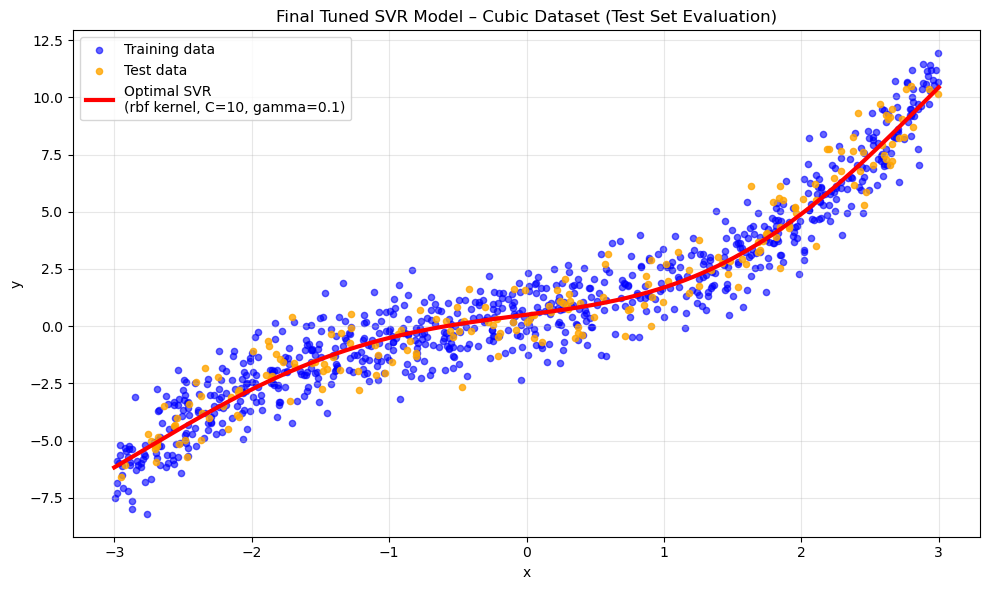

In [8]:
# Visualise the final fitted regression function
plt.figure(figsize=(10, 6))

# Plot training and test points
plt.scatter(X_train_cubic.flatten(), y_train_cubic, s=20, alpha=0.6, color='blue', label='Training data')
plt.scatter(X_test_cubic.flatten(), y_test_cubic, s=20, alpha=0.8, color='orange', label='Test data')

# Predict on dense grid for smooth curve
x_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
y_plot = best_model.predict(x_plot)

plt.plot(x_plot.flatten(), y_plot, 'r-', linewidth=3, label=f'Optimal SVR\n({best_model.kernel} kernel, C={best_model.C}, gamma={best_model.gamma})')

plt.title('Final Tuned SVR Model – Cubic Dataset (Test Set Evaluation)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

**Results Summary**  

The optimal model (RBF kernel, \( C = 10 \), \( \gamma = 0.1 \)) achieves excellent generalisation on the unseen test set:

- **Test \( R^2 \)**:  0.946 (very high, indicating the model explains over 94% of the variance in the test data)  
- **Test RMSE**:  0.9522 (close to the noise level of \( \sigma = 1 \), showing the model has successfully recovered the underlying cubic polynomial)  
- **Test MAE**:  0.7395  

**Visual inspection** (see plot above) confirms that the fitted curve closely follows both training and test points with no obvious systematic bias or overfitting. The model adapts well to the cubic shape while remaining robust to the added Gaussian noise.

**Conclusion**  
Hyperparameter tuning via grid search with 5-fold cross-validation significantly improved the SVR’s ability to model the complex cubic relationship. The final model generalises cleanly to the test set, demonstrating the power of kernel methods (especially RBF) when the appropriate regularisation parameters are selected. This completes the investigation into how different kernels and hyperparameters affect SVM regression performance on synthetic polynomial data.